In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Load dataset
df = pd.read_csv("../../Final_data/KO.csv")

# Display first 5 rows
df.head()

,Date,Volume,Open,High,Low,Close,Adj close,Sentiment_gpt,News_flag,Scaled_sentiment
0,2009-10-14 00:00:00+00:00,16081000.0,27.459999,27.514999,27.295000,27.420000,18.121803,2.0,1.0,0.250025
1,2009-10-15 00:00:00+00:00,24241800.0,27.365000,27.605000,27.174999,27.459999,18.148237,3.0,1.0,0.500025
2,2009-10-16 00:00:00+00:00,22090800.0,27.459999,27.600000,27.344999,27.504999,18.177977,3.0,0.0,0.500025
3,2009-10-19 00:00:00+00:00,20656000.0,27.570000,27.750000,27.334999,27.395000,18.105282,3.0,0.0,0.500025
4,2009-10-20 00:00:00+00:00,26859600.0,26.795000,27.075001,26.590000,27.035000,17.867361,3.0,0.0,0.500025


In [3]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (3568, 10)

Column names:
['Date', 'Volume', 'Open', 'High', 'Low', 'Close', 'Adj close', 'Sentiment_gpt', 'News_flag', 'Scaled_sentiment']

Data types:
Date                 object
Volume              float64
Open                float64
High                float64
Low                 float64
Close               float64
Adj close           float64
Sentiment_gpt       float64
News_flag           float64
Scaled_sentiment    float64
dtype: object

Missing values:
Date                0
Volume              0
Open                0
High                0
Low                 0
Close               0
Adj close           0
Sentiment_gpt       0
News_flag           0
Scaled_sentiment    0
dtype: int64


In [4]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort by date
df = df.sort_values("Date").reset_index(drop=True)

# Set Date as index
df.set_index("Date", inplace=True)

# Display first and last few rows
print("First 5 rows:")
display(df.head())

print("Last 5 rows:")
display(df.tail())

First 5 rows:


,Volume,Open,High,Low,Close,Adj close,Sentiment_gpt,News_flag,Scaled_sentiment
Date,,,,,,,,,
2009-10-14 00:00:00+00:00,16081000.0,27.459999,27.514999,27.295000,27.420000,18.121803,2.0,1.0,0.250025
2009-10-15 00:00:00+00:00,24241800.0,27.365000,27.605000,27.174999,27.459999,18.148237,3.0,1.0,0.500025
2009-10-16 00:00:00+00:00,22090800.0,27.459999,27.600000,27.344999,27.504999,18.177977,3.0,0.0,0.500025
2009-10-19 00:00:00+00:00,20656000.0,27.570000,27.750000,27.334999,27.395000,18.105282,3.0,0.0,0.500025
2009-10-20 00:00:00+00:00,26859600.0,26.795000,27.075001,26.590000,27.035000,17.867361,3.0,0.0,0.500025


Last 5 rows:


,Volume,Open,High,Low,Close,Adj close,Sentiment_gpt,News_flag,Scaled_sentiment
Date,,,,,,,,,
2023-12-11 00:00:00+00:00,14524800.0,58.830002,59.090000,58.500000,59.040001,59.040001,3.900000,1.0,0.725025
2023-12-12 00:00:00+00:00,12899000.0,59.200001,59.419998,58.900002,59.419998,59.419998,3.800000,1.0,0.700025
2023-12-13 00:00:00+00:00,16196800.0,59.450001,60.020000,59.259998,59.930000,59.930000,3.875000,1.0,0.718775
2023-12-14 00:00:00+00:00,22478300.0,59.970001,60.040001,58.770000,59.040001,59.040001,4.000000,1.0,0.750025
2023-12-15 00:00:00+00:00,65172300.0,58.830002,59.169998,57.799999,58.599998,58.599998,4.111111,1.0,0.777803


In [5]:
df.describe()

,Volume,Open,High,Low,Close,Adj close,Sentiment_gpt,News_flag,Scaled_sentiment
count,3.568000e+03,3568.000000,3568.000000,3568.000000,3568.000000,3568.000000,3568.000000,3568.000000,3568.000000
mean,1.510865e+07,44.705512,45.000171,44.401463,44.707365,39.434797,3.122656,0.711603,0.530689
std,6.711424e+06,9.628031,9.701854,9.544764,9.622465,12.003108,0.691145,0.453080,0.172786
min,2.996300e+06,25.110001,25.150000,24.735001,25.014999,17.062767,1.000000,0.000000,0.000025
25%,1.088708e+07,38.646251,38.837501,38.407500,38.630001,30.873659,2.800000,0.000000,0.450025
50%,1.365080e+07,43.340000,43.645000,43.094999,43.360001,38.341143,3.000000,1.000000,0.500025
75%,1.749342e+07,51.962500,52.192499,51.557500,51.985000,48.629961,3.500000,1.000000,0.625025
max,9.896750e+07,67.000000,67.199997,65.720001,66.209999,62.817852,5.000000,1.000000,1.000025


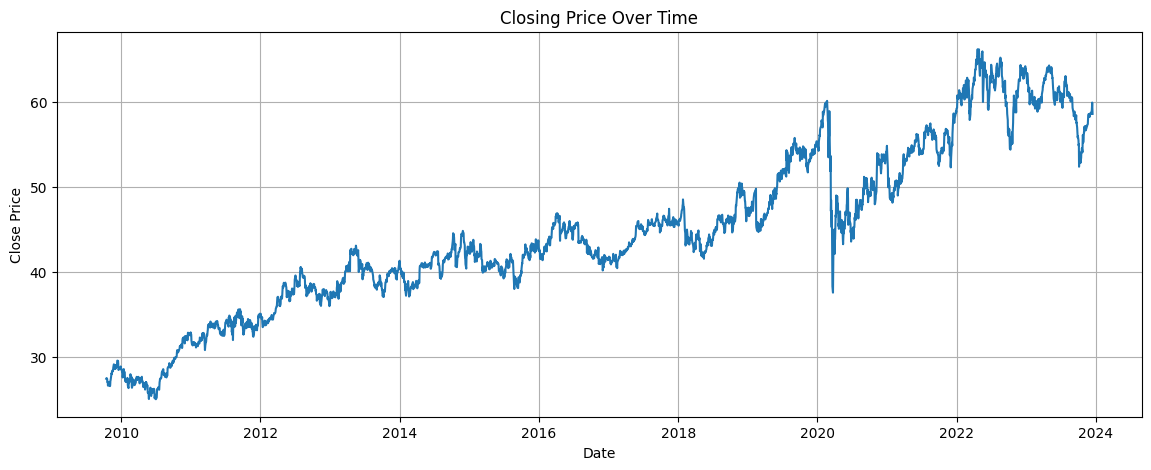

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Close"])
plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

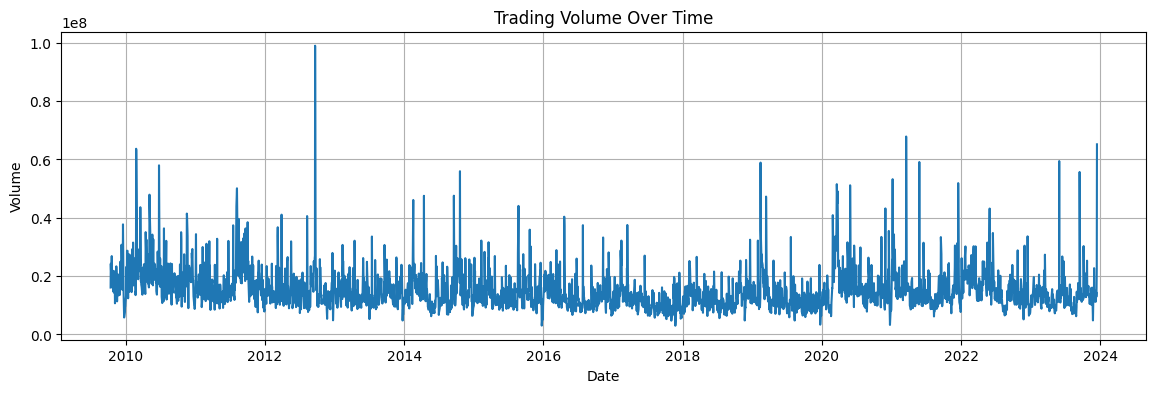

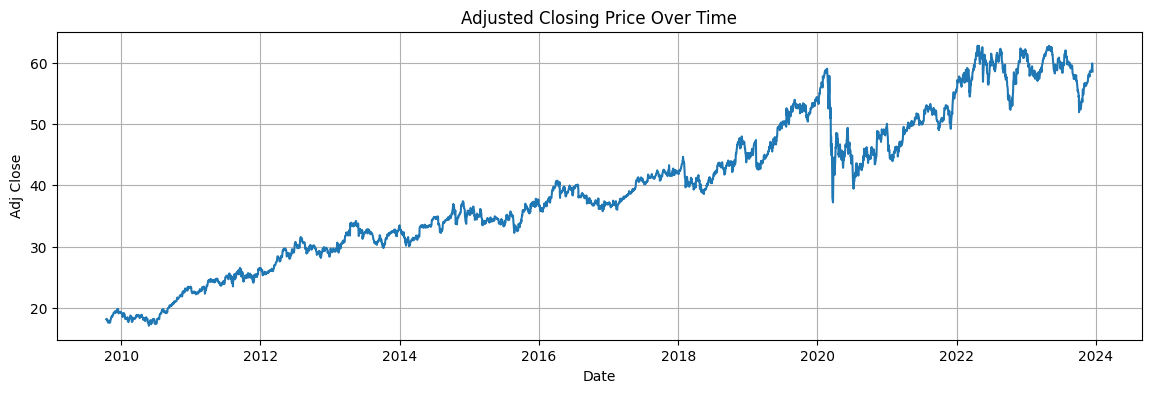

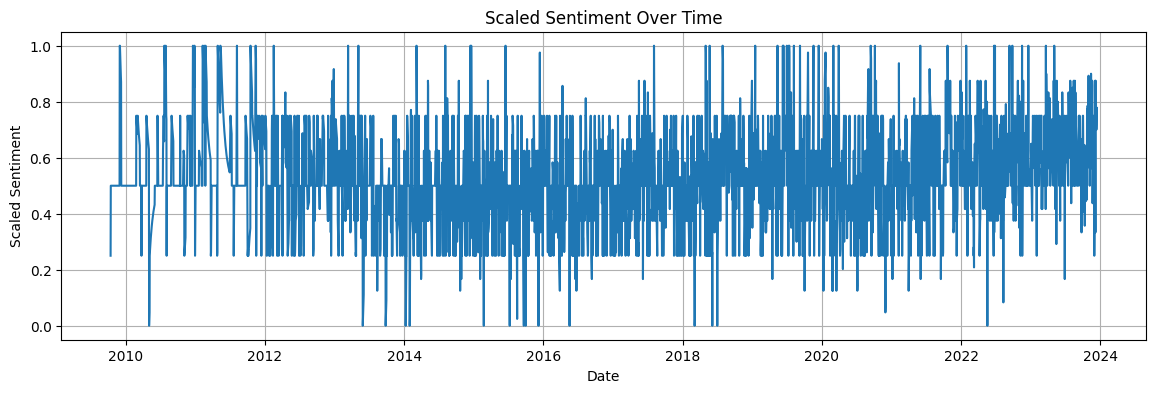

In [7]:
plt.figure(figsize=(14, 4))
plt.plot(df.index, df["Volume"])
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(df.index, df["Adj close"])
plt.title("Adjusted Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Adj Close")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(df.index, df["Scaled_sentiment"])
plt.title("Scaled Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Scaled Sentiment")
plt.grid(True)
plt.show()

In [8]:
def adf_test(series, series_name="Series"):
    result = adfuller(series.dropna())
    
    print(f"ADF Test for {series_name}")
    print("-" * 40)
    print(f"ADF Statistic : {result[0]:.6f}")
    print(f"p-value       : {result[1]:.6f}")
    print(f"Lags Used     : {result[2]}")
    print(f"Observations  : {result[3]}")
    
    print("\nCritical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.6f}")
    
    if result[1] < 0.05:
        print(f"\nConclusion: {series_name} is STATIONARY.")
    else:
        print(f"\nConclusion: {series_name} is NON-STATIONARY.")

In [9]:
adf_test(df["Close"], "Raw Close Price")

ADF Test for Raw Close Price
----------------------------------------
ADF Statistic : -1.642299
p-value       : 0.461060
Lags Used     : 13
Observations  : 3554

Critical Values:
   1%: -3.432191
   5%: -2.862354
   10%: -2.567203

Conclusion: Raw Close Price is NON-STATIONARY.


In [10]:
df["Close_diff_1"] = df["Close"].diff()

df[["Close", "Close_diff_1"]].head(10)

,Close,Close_diff_1
Date,,
2009-10-14 00:00:00+00:00,27.420000,NaN
2009-10-15 00:00:00+00:00,27.459999,0.039999
2009-10-16 00:00:00+00:00,27.504999,0.045000
2009-10-19 00:00:00+00:00,27.395000,-0.109999
2009-10-20 00:00:00+00:00,27.035000,-0.360001
2009-10-21 00:00:00+00:00,27.035000,0.000000
2009-10-22 00:00:00+00:00,27.075001,0.040001
2009-10-23 00:00:00+00:00,26.620001,-0.455000
2009-10-26 00:00:00+00:00,26.615000,-0.005001


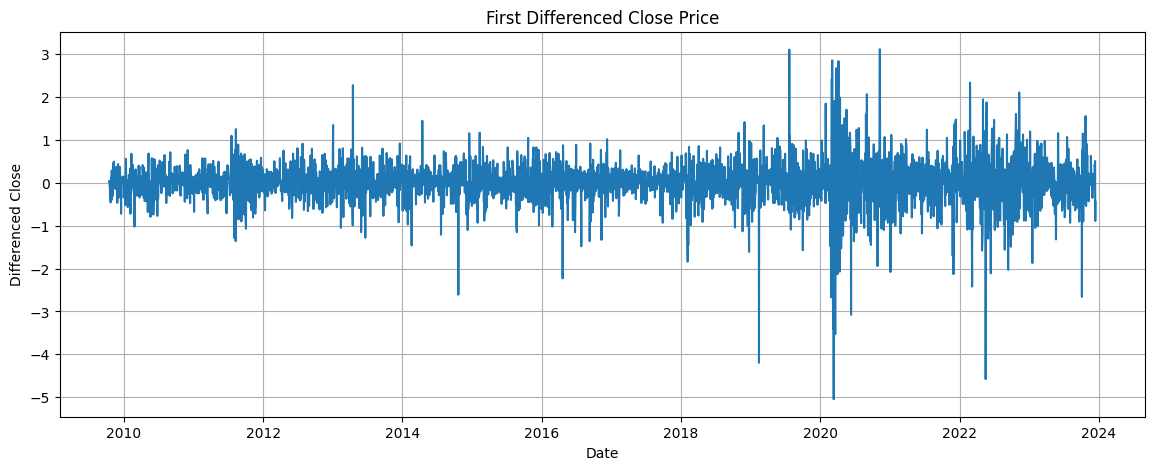

In [11]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Close_diff_1"])
plt.title("First Differenced Close Price")
plt.xlabel("Date")
plt.ylabel("Differenced Close")
plt.grid(True)
plt.show()

In [12]:
adf_test(df["Close_diff_1"], "First Differenced Close Price")

ADF Test for First Differenced Close Price
----------------------------------------
ADF Statistic : -17.925807
p-value       : 0.000000
Lags Used     : 12
Observations  : 3554

Critical Values:
   1%: -3.432191
   5%: -2.862354
   10%: -2.567203

Conclusion: First Differenced Close Price is STATIONARY.


In [14]:
df["Log_Close"] = np.log(df["Close"])
df["Log_Return"] = df["Log_Close"].diff()

df[["Close", "Log_Close", "Log_Return"]].head(10)

,Close,Log_Close,Log_Return
Date,,,
2009-10-14 00:00:00+00:00,27.420000,3.311273,NaN
2009-10-15 00:00:00+00:00,27.459999,3.312730,0.001458
2009-10-16 00:00:00+00:00,27.504999,3.314368,0.001637
2009-10-19 00:00:00+00:00,27.395000,3.310361,-0.004007
2009-10-20 00:00:00+00:00,27.035000,3.297132,-0.013228
2009-10-21 00:00:00+00:00,27.035000,3.297132,0.000000
2009-10-22 00:00:00+00:00,27.075001,3.298611,0.001479
2009-10-23 00:00:00+00:00,26.620001,3.281663,-0.016948
2009-10-26 00:00:00+00:00,26.615000,3.281475,-0.000188


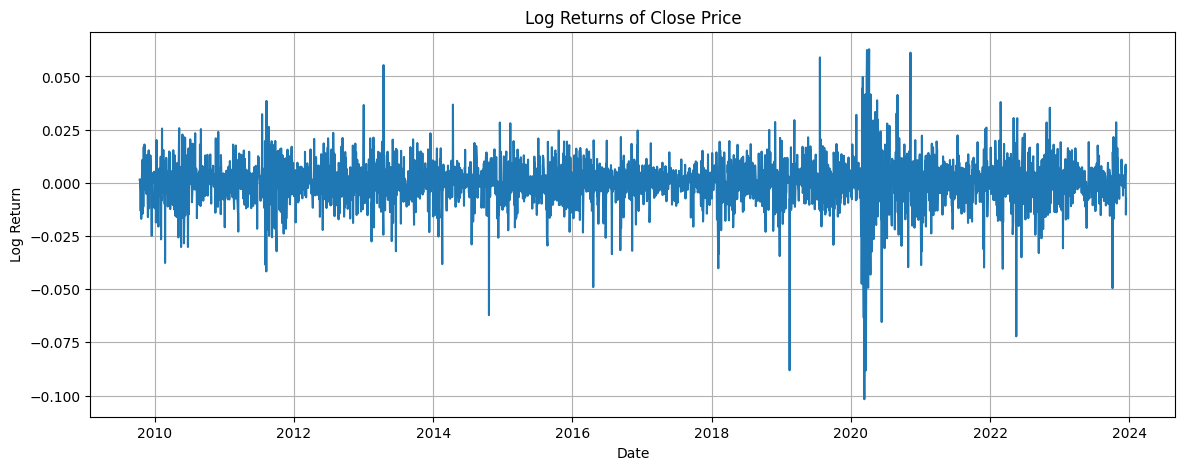

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Log_Return"])
plt.title("Log Returns of Close Price")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True)
plt.show()

In [17]:
final_df = df[["Close", "Close_diff_1", "Log_Return"]].dropna()
final_df.head()

,Close,Close_diff_1,Log_Return
Date,,,
2009-10-15 00:00:00+00:00,27.459999,0.039999,0.001458
2009-10-16 00:00:00+00:00,27.504999,0.045000,0.001637
2009-10-19 00:00:00+00:00,27.395000,-0.109999,-0.004007
2009-10-20 00:00:00+00:00,27.035000,-0.360001,-0.013228
2009-10-21 00:00:00+00:00,27.035000,0.000000,0.000000


In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

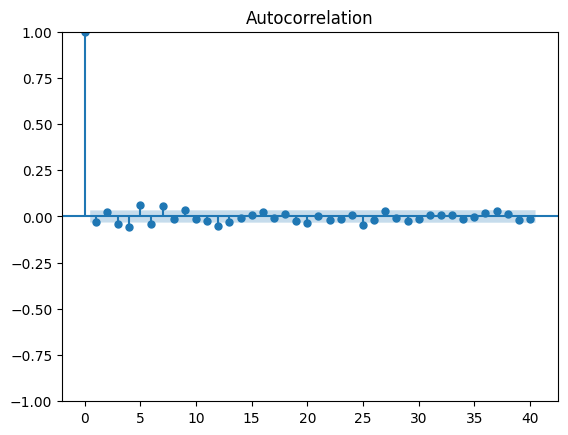

In [19]:
plot_acf(final_df['Close_diff_1'], lags=40)
plt.show()

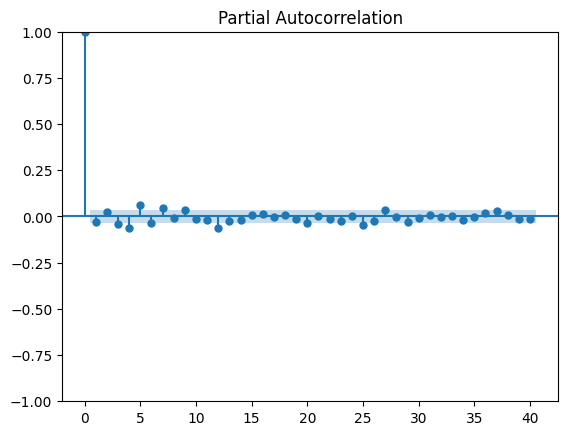

In [20]:
plot_pacf(final_df['Close_diff_1'], lags=40)
plt.show()

Since ACF and PACF plots do not show significant spikes, initial values p=0 and q=0 were selected. However, alternative models were also tested to improve performance

In [ ]:
target = df["Close"]

n = len(target)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = target.iloc[:train_end]
val = target.iloc[train_end:val_end]
test = target.iloc[val_end:]

print("Training size   :", len(train))
print("Validation size :", len(val))
print("Test size       :", len(test))

Training size   : 2497
Validation size : 535
Test size       : 536


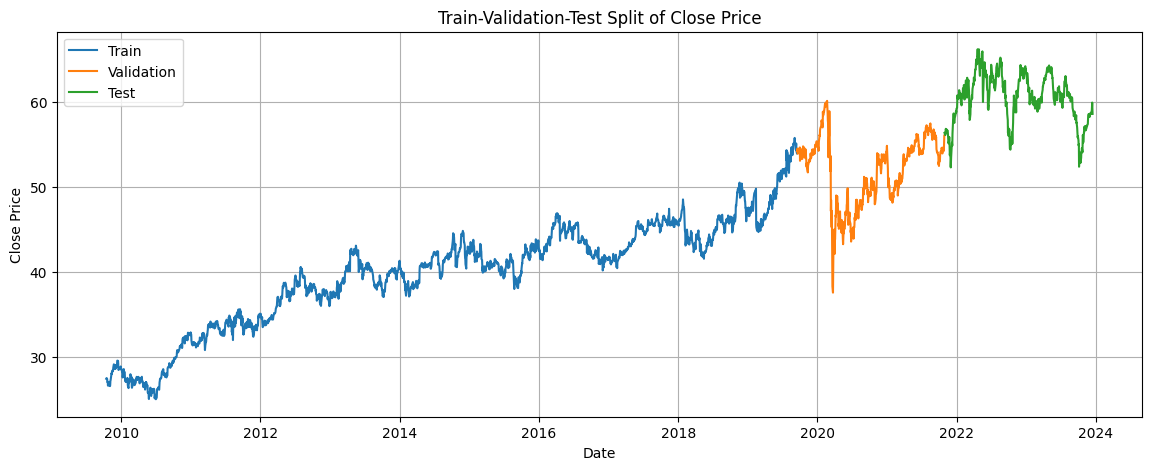

In [27]:
plt.figure(figsize=(14, 5))

plt.plot(train.index, train, label="Train")
plt.plot(val.index, val, label="Validation")
plt.plot(test.index, test, label="Test")

plt.title("Train-Validation-Test Split of Close Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

In [52]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def evaluate_arima(train, val, order):
    
    model = ARIMA(train, order=order)
    model_fit = model.fit()
    
    forecast = model_fit.forecast(steps=len(val))
    
    # Convert to Series properly
    forecast = pd.Series(forecast)
    
    # FORCE correct alignment (important)
    forecast.index = val.index[:len(forecast)]
    
    # Combine safely
    df_eval = pd.concat([val, forecast], axis=1)
    df_eval.columns = ['actual', 'pred']
    
    print("Before drop:", df_eval.shape)
    print(df_eval.isna().sum())
    
    df_eval = df_eval.dropna()
    
    print("After drop:", df_eval.shape)
    
    if len(df_eval) == 0:
        raise ValueError("No overlapping data after alignment. Check index.")
    
    # Metrics
    mae = mean_absolute_error(df_eval['actual'], df_eval['pred'])
    rmse = np.sqrt(mean_squared_error(df_eval['actual'], df_eval['pred']))
    r2 = r2_score(df_eval['actual'], df_eval['pred'])
    
    return mae, rmse, r2, model_fit, df_eval

In [53]:
orders = [(0,1,0), (1,1,0), (0,1,1), (1,1,1)]

results = []

for order in orders:
    mae, rmse, r2, model_fit, df_eval = evaluate_arima(train, val, order)
    
    print(f"Order {order} → MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")
    
    results.append((order, mae, rmse, r2))

Before drop: (535, 2)
actual    0
pred      0
dtype: int64
After drop: (535, 2)
Order (0, 1, 0) → MAE: 3.3232, RMSE: 4.4846, R2: -0.2648
Before drop: (535, 2)
actual    0
pred      0
dtype: int64
After drop: (535, 2)
Order (1, 1, 0) → MAE: 3.3253, RMSE: 4.4884, R2: -0.2669
Before drop: (535, 2)
actual    0
pred      0
dtype: int64
After drop: (535, 2)
Order (0, 1, 1) → MAE: 3.3257, RMSE: 4.4891, R2: -0.2673
Before drop: (535, 2)
actual    0
pred      0
dtype: int64
After drop: (535, 2)
Order (1, 1, 1) → MAE: 3.3520, RMSE: 4.5335, R2: -0.2925


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarnin

In [54]:
import pandas as pd

# Your results list already exists like:
# results = [(order, mae, rmse, r2), ...]

results_df = pd.DataFrame(results, columns=['Order', 'MAE', 'RMSE', 'R2'])

# Sort by RMSE (best model on top)
results_df = results_df.sort_values(by='RMSE')

print(results_df)

       Order       MAE      RMSE        R2
0  (0, 1, 0)  3.323233  4.484639 -0.264772
1  (1, 1, 0)  3.325315  4.488365 -0.266875
2  (0, 1, 1)  3.325746  4.489136 -0.267310
3  (1, 1, 1)  3.351993  4.533452 -0.292455


In [55]:
results_df.style.format({
    'MAE': "{:.4f}",
    'RMSE': "{:.4f}",
    'R2': "{:.4f}"
})

,Order,MAE,RMSE,R2
0,"(0, 1, 0)",3.3232,4.4846,-0.2648
1,"(1, 1, 0)",3.3253,4.4884,-0.2669
2,"(0, 1, 1)",3.3257,4.4891,-0.2673
3,"(1, 1, 1)",3.3520,4.5335,-0.2925


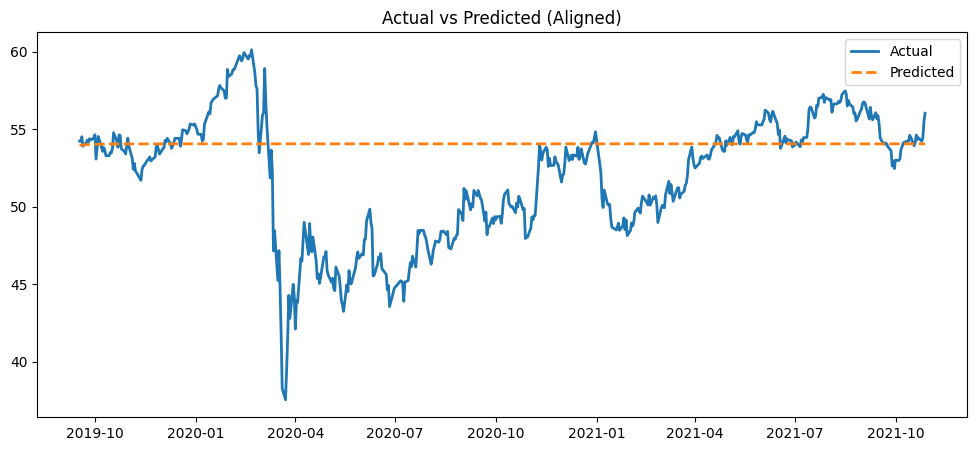

In [58]:
plt.figure(figsize=(12,5))

plt.plot(df_eval['actual'], label='Actual', linewidth=2)
plt.plot(df_eval['pred'], label='Predicted', linestyle='--', linewidth=2)

plt.legend()
plt.title('Actual vs Predicted (Aligned)')
plt.show()

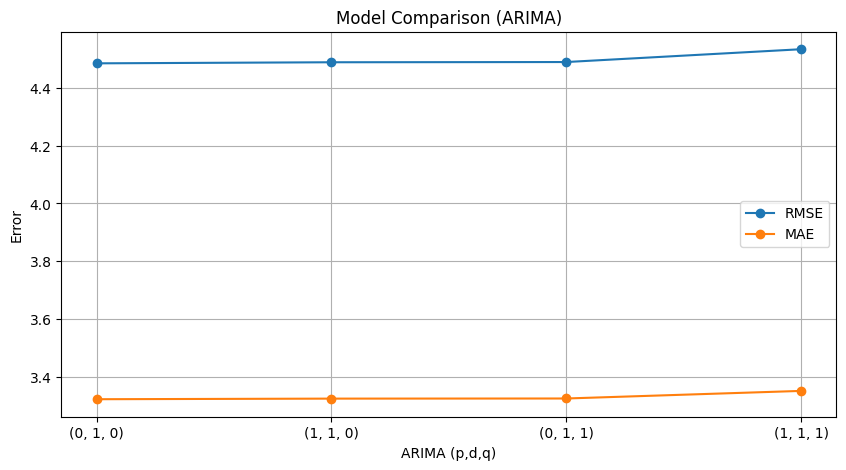

In [56]:
import matplotlib.pyplot as plt

# Convert order to string for plotting
results_df['Order_str'] = results_df['Order'].astype(str)

plt.figure(figsize=(10,5))
plt.plot(results_df['Order_str'], results_df['RMSE'], marker='o', label='RMSE')
plt.plot(results_df['Order_str'], results_df['MAE'], marker='o', label='MAE')

plt.xlabel('ARIMA (p,d,q)')
plt.ylabel('Error')
plt.title('Model Comparison (ARIMA)')
plt.legend()
plt.grid(True)
plt.show()

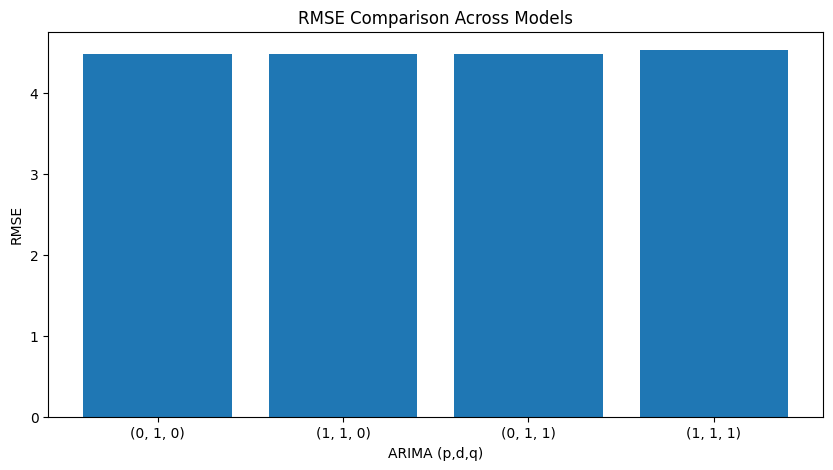

In [57]:
plt.figure(figsize=(10,5))

plt.bar(results_df['Order_str'], results_df['RMSE'])

plt.xlabel('ARIMA (p,d,q)')
plt.ylabel('RMSE')
plt.title('RMSE Comparison Across Models')

plt.show()

In [59]:
best_order = results_df.iloc[0]['Order']
print("Best Model:", best_order)

Best Model: (0, 1, 0)


In [60]:
orders = [(0,1,0), (1,1,0), (0,1,1), (1,1,1), (0,2,1), (1,2,1), (0,2,2), (1,2,2), (2,1,0), (2,1,1), (2,2,1), (2,2,2)]

results = []

for order in orders:
    mae, rmse, r2, model_fit, df_eval = evaluate_arima(train, val, order)
    
    print(f"Order {order} → MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")
    
    results.append((order, mae, rmse, r2))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarnin

Before drop: (535, 2)
actual    0
pred      0
dtype: int64
After drop: (535, 2)
Order (0, 1, 0) → MAE: 3.3232, RMSE: 4.4846, R2: -0.2648
Before drop: (535, 2)
actual    0
pred      0
dtype: int64
After drop: (535, 2)
Order (1, 1, 0) → MAE: 3.3253, RMSE: 4.4884, R2: -0.2669
Before drop: (535, 2)
actual    0
pred      0
dtype: int64
After drop: (535, 2)
Order (0, 1, 1) → MAE: 3.3257, RMSE: 4.4891, R2: -0.2673
Before drop: (535, 2)
actual    0
pred      0
dtype: int64
After drop: (535, 2)
Order (1, 1, 1) → MAE: 3.3520, RMSE: 4.5335, R2: -0.2925


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index 

Before drop: (535, 2)
actual    0
pred      0
dtype: int64
After drop: (535, 2)
Order (0, 2, 1) → MAE: 5.3465, RMSE: 6.3074, R2: -1.5018


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index 

...

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index 

Before drop: (535, 2)
actual    0
pred      0
dtype: int64
After drop: (535, 2)
Order (1, 2, 2) → MAE: 5.3437, RMSE: 6.3047, R2: -1.4997
Before drop: (535, 2)
actual    0
pred      0
dtype: int64
After drop: (535, 2)
Order (2, 1, 0) → MAE: 3.3360, RMSE: 4.5071, R2: -0.2775
Before drop: (535, 2)
actual    0
pred      0
dtype: int64
After drop: (535, 2)
Order (2, 1, 1) → MAE: 3.3590, RMSE: 4.5448, R2: -0.2990


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index 

Before drop: (535, 2)
actual    0
pred      0
dtype: int64
After drop: (535, 2)
Order (2, 2, 1) → MAE: 5.3895, RMSE: 6.3502, R2: -1.5359
Before drop: (535, 2)
actual    0
pred      0
dtype: int64
After drop: (535, 2)
Order (2, 2, 2) → MAE: 5.3632, RMSE: 6.3233, R2: -1.5145


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [61]:
import pandas as pd

# Your results list already exists like:
# results = [(order, mae, rmse, r2), ...]

results_df = pd.DataFrame(results, columns=['Order', 'MAE', 'RMSE', 'R2'])

# Sort by RMSE (best model on top)
results_df = results_df.sort_values(by='RMSE')

results_df.style.format({
    'MAE': "{:.4f}",
    'RMSE': "{:.4f}",
    'R2': "{:.4f}"
})

,Order,MAE,RMSE,R2
0,"(0, 1, 0)",3.3232,4.4846,-0.2648
1,"(1, 1, 0)",3.3253,4.4884,-0.2669
2,"(0, 1, 1)",3.3257,4.4891,-0.2673
8,"(2, 1, 0)",3.3360,4.5071,-0.2775
3,"(1, 1, 1)",3.3520,4.5335,-0.2925
9,"(2, 1, 1)",3.3590,4.5448,-0.2990
7,"(1, 2, 2)",5.3437,6.3047,-1.4997
4,"(0, 2, 1)",5.3465,6.3074,-1.5018
5,"(1, 2, 1)",5.3533,6.3143,-1.5073
6,"(0, 2, 2)",5.3551,6.3160,-1.5087


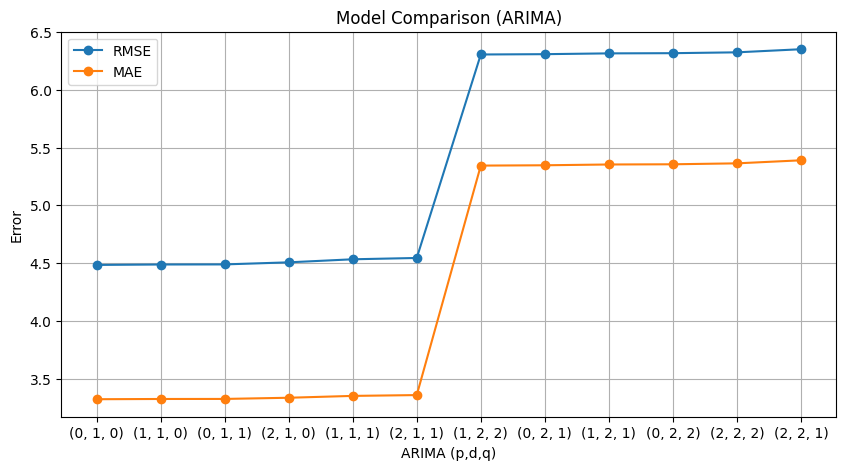

In [62]:
import matplotlib.pyplot as plt

# Convert order to string for plotting
results_df['Order_str'] = results_df['Order'].astype(str)

plt.figure(figsize=(10,5))
plt.plot(results_df['Order_str'], results_df['RMSE'], marker='o', label='RMSE')
plt.plot(results_df['Order_str'], results_df['MAE'], marker='o', label='MAE')

plt.xlabel('ARIMA (p,d,q)')
plt.ylabel('Error')
plt.title('Model Comparison (ARIMA)')
plt.legend()
plt.grid(True)
plt.show()

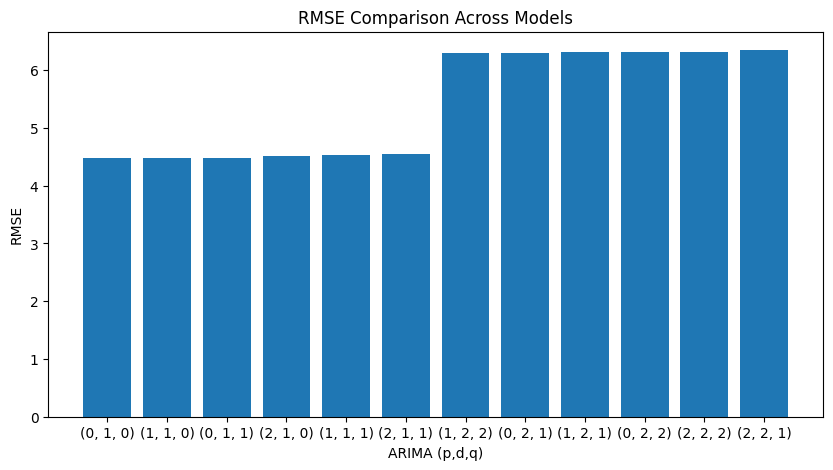

In [63]:
plt.figure(figsize=(10,5))

plt.bar(results_df['Order_str'], results_df['RMSE'])

plt.xlabel('ARIMA (p,d,q)')
plt.ylabel('RMSE')
plt.title('RMSE Comparison Across Models')

plt.show()

still best model (0, 1, 0)